In [100]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [101]:
df_train = pd.read_csv('train.csv')
df_test = pd.read_csv('test.csv')

In [118]:
df_train

,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,0,3,1,22.0,1,0,523,7.2500,147,S
1,1,1,0,38.0,1,0,596,71.2833,81,C
2,1,3,0,26.0,0,0,669,7.9250,147,S
3,1,1,0,35.0,1,0,49,53.1000,55,S
4,0,3,1,35.0,0,0,472,8.0500,147,S
...,...,...,...,...,...,...,...,...,...,...
886,0,2,1,27.0,0,0,101,13.0000,147,S
887,1,1,0,19.0,0,0,14,30.0000,30,S
888,0,3,0,28.0,1,2,675,23.4500,147,S
889,1,1,1,26.0,0,0,8,30.0000,60,C


In [119]:
df_test

,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,3,1,34.5,0,0,152,7.8292,76,Q
1,3,0,47.0,1,0,221,7.0000,76,S
2,2,1,62.0,0,0,73,9.6875,76,Q
3,3,1,27.0,0,0,147,8.6625,76,S
4,3,0,22.0,1,1,138,12.2875,76,S
...,...,...,...,...,...,...,...,...,...
413,3,1,28.0,0,0,267,8.0500,76,S
414,1,0,39.0,0,0,324,108.9000,22,C
415,3,1,38.5,0,0,346,7.2500,76,S
416,3,1,28.0,0,0,220,8.0500,76,S


In [120]:
df_train.isna().sum()

Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Ticket      0
Fare        0
Cabin       0
Embarked    0
dtype: int64

In [121]:
df_test.isna().sum()

Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Ticket      0
Fare        0
Cabin       0
Embarked    0
dtype: int64

In [122]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    int64  
 3   Age       891 non-null    float64
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Ticket    891 non-null    int64  
 7   Fare      891 non-null    float64
 8   Cabin     891 non-null    int64  
 9   Embarked  891 non-null    object 
dtypes: float64(2), int64(7), object(1)
memory usage: 69.7+ KB


In [107]:
df_train = df_train.drop('PassengerId',axis = 1)
df_test = df_test.drop('PassengerId',axis = 1)

In [108]:
df_train = df_train.drop('Name',axis = 1)
df_test = df_test.drop('Name',axis = 1)

In [109]:
from sklearn.preprocessing import LabelEncoder
label = LabelEncoder()

In [110]:
df_train['Sex'] = label.fit_transform(df_train['Sex'])
df_test['Sex'] = label.fit_transform(df_test['Sex'])

In [111]:
df_train['Age'] = pd.to_numeric(df_train['Age'],errors='coerce')
df_test['Age'] = pd.to_numeric(df_test['Age'],errors='coerce')
median_hs = df_train['Age'].median()
df_train['Age'] = df_train['Age'].fillna(median_hs)
df_test['Age'] = df_test['Age'].fillna(median_hs)


In [112]:
df_train['Ticket'] = label.fit_transform(df_train['Ticket'])
df_test['Ticket'] = label.fit_transform(df_test['Ticket'])

In [113]:
df_train['Fare'] = pd.to_numeric(df_train['Fare'],errors='coerce')
df_test['Fare'] = pd.to_numeric(df_test['Fare'],errors='coerce')
median_hs = df_train['Fare'].median()
df_train['Fare'] = df_train['Fare'].fillna(median_hs)
df_test['Fare'] = df_test['Fare'].fillna(median_hs)

In [114]:
df_train["Cabin"] = df_train["Cabin"].fillna("Unknown")


In [115]:
df_train['Cabin'] = label.fit_transform(df_train['Cabin'])
df_test['Cabin'] = label.fit_transform(df_test['Cabin'])

In [116]:
df_train['Embarked'] = df_train['Embarked'].fillna(
    df_train['Embarked'].mode()[0]
)

In [123]:
df_train['Embarked'] = label.fit_transform(df_train['Embarked'])
df_test['Embarked'] = label.fit_transform(df_test['Embarked'])

In [124]:
X = df_train.drop('Survived', axis=1)
y = df_train['Survived']

In [125]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier

In [126]:
model = DecisionTreeClassifier()

In [127]:
params = {
    'criterion':["gini", "entropy", "log_loss"],
    'splitter':['best','random'],
    'max_depth':[4,5,6,8,10,12]
}

In [129]:
final_model = GridSearchCV(model,params,cv = 3,verbose = 2)

In [130]:
X_train = df_train.drop('Survived', axis=1)
y_train = df_train['Survived']
X_test = df_test.copy()

In [131]:
final_model.fit(X_train,y_train)

Fitting 3 folds for each of 36 candidates, totalling 108 fits
[CV] END .........criterion=gini, max_depth=4, splitter=best; total time=   0.0s
[CV] END .........criterion=gini, max_depth=4, splitter=best; total time=   0.0s
[CV] END .........criterion=gini, max_depth=4, splitter=best; total time=   0.0s
[CV] END .......criterion=gini, max_depth=4, splitter=random; total time=   0.0s
[CV] END .......criterion=gini, max_depth=4, splitter=random; total time=   0.0s
[CV] END .......criterion=gini, max_depth=4, splitter=random; total time=   0.0s
[CV] END .........criterion=gini, max_depth=5, splitter=best; total time=   0.0s
[CV] END .........criterion=gini, max_depth=5, splitter=best; total time=   0.0s
[CV] END .........criterion=gini, max_depth=5, splitter=best; total time=   0.0s
[CV] END .......criterion=gini, max_depth=5, splitter=random; total time=   0.0s
[CV] END .......criterion=gini, max_depth=5, splitter=random; total time=   0.0s
[CV] END .......criterion=gini, max_depth=5, sp

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'criterion': ['gini', 'entropy', ...], 'max_depth': [4, 5, ...], 'splitter': ['best', 'random']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 :

In [132]:
final_tree = final_model.best_estimator_

In [133]:
final_model.best_params_

{'criterion': 'gini', 'max_depth': 5, 'splitter': 'best'}

In [134]:
from sklearn.tree import plot_tree

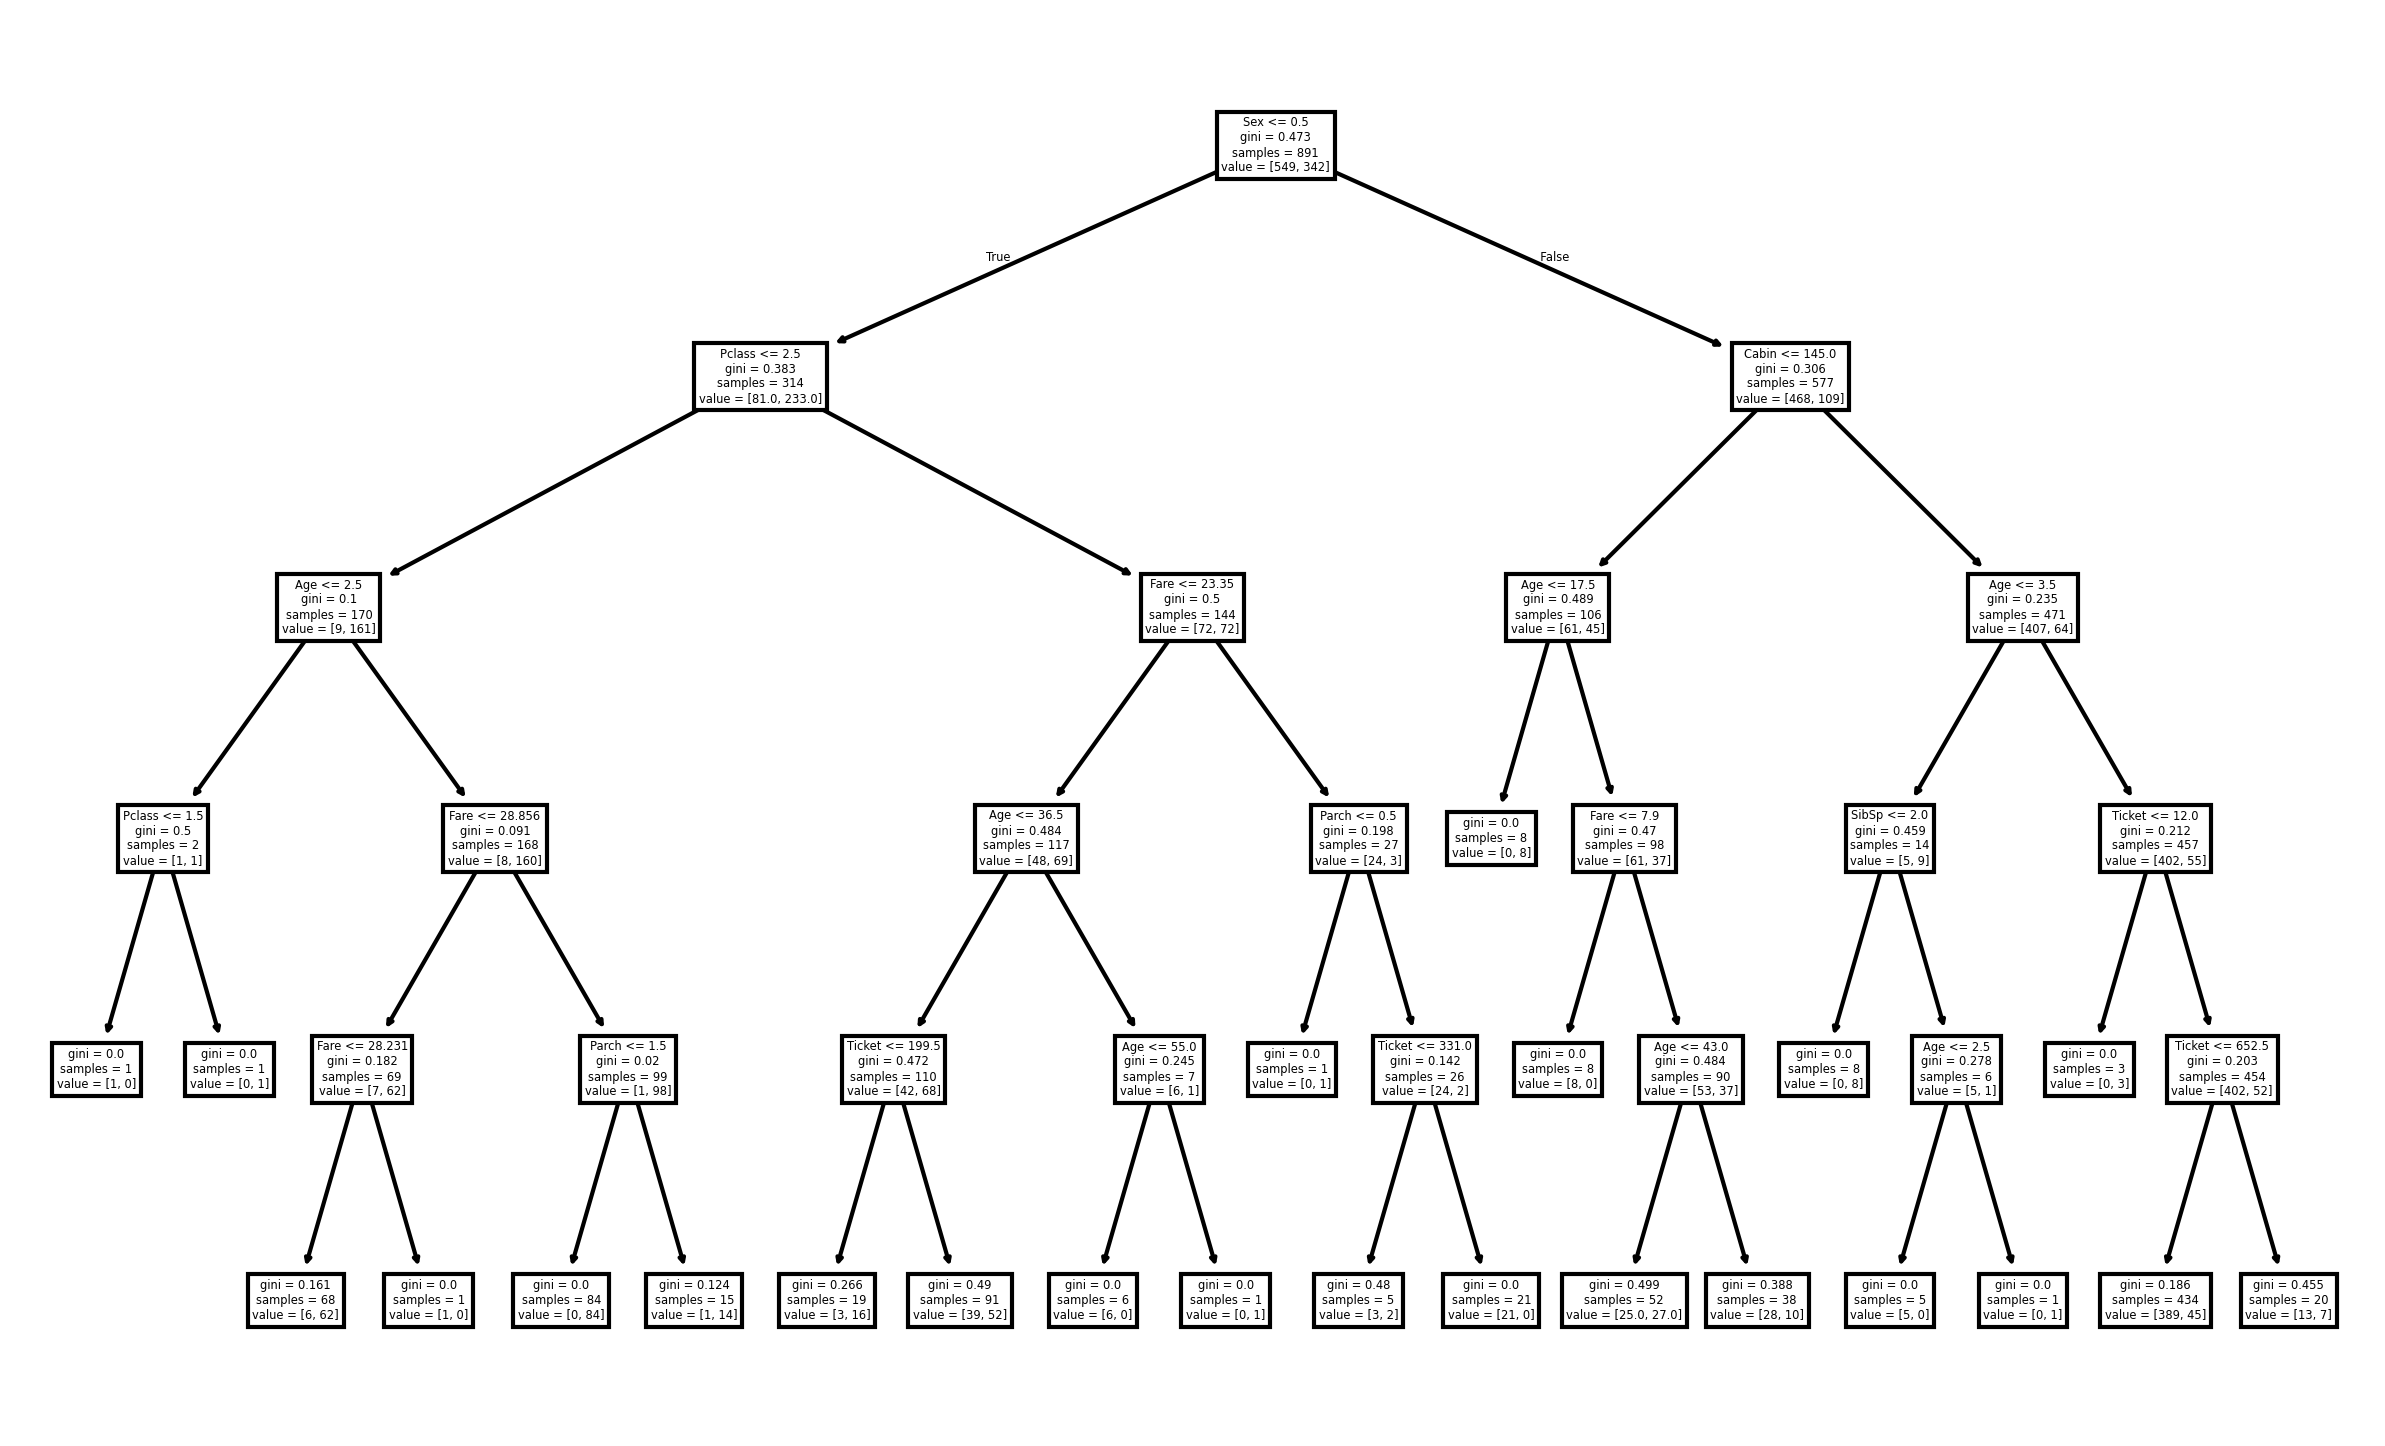

In [135]:
plt.figure(figsize=(10, 6), dpi=300)
plot_tree(final_tree, feature_names=X.columns)
plt.show()

In [136]:
y_pred = final_model.predict(X_test)

In [137]:
df_sub = pd.read_csv('gender_submission.csv')

In [138]:
df_sub['Survived'] = y_pred

In [139]:
df_sub.to_csv('sub.csv',index = False,index_label=False)

In [140]:
df_sub

,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,1
4,896,1
...,...,...
413,1305,1
414,1306,1
415,1307,0
416,1308,1
